In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from collections import Counter
import numpy as np
from scipy.stats import randint

In [24]:
df=pd.read_csv("C:/Users/HARINI/OneDrive/Desktop/streamlit/pizza.csv")

In [25]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13,13,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16,16,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18,18,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20,20,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16,16,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16,16,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17,17,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12,12,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20,20,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [26]:
df.isna().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [27]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include=['object']).columns

# Create a new LabelEncoder instance
le_df = LabelEncoder()

# Apply LabelEncoder to each categorical column
label_encoders = {}
for column in categorical_cols:
    le = LabelEncoder()  # create a fresh encoder for each column
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
df.head()    

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,27,1,0,415,13,13,1,1,23,12
1,2,2,18,1,0,912,16,16,1,1,20,7
2,3,2,20,1,0,912,18,18,0,3,17,8
3,4,2,32,1,0,912,20,20,0,2,4,14
4,5,2,42,1,0,912,16,16,1,3,31,17


In [28]:
df.isna().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

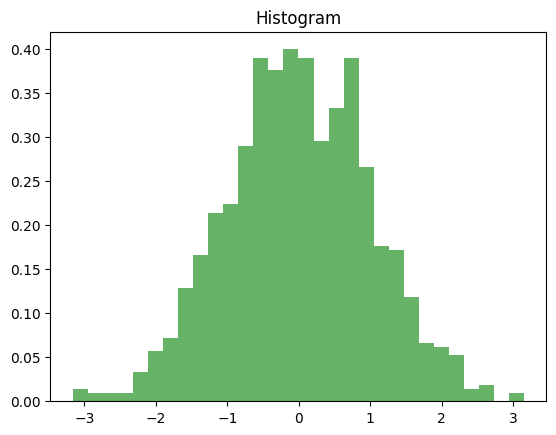

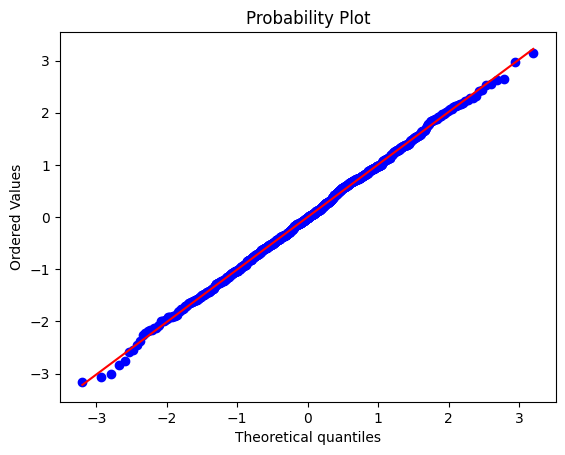

Shapiro-Wilk Test: Statistics=0.999, p=0.903
Data looks Gaussian (normal distribution)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Example data
data = np.random.normal(loc=0, scale=1, size=1000)

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
plt.title("Histogram")
plt.show()

# Q-Q Plot
stats.probplot(data, dist="norm", plot=plt)
plt.show()

# Shapiro-Wilk Test
stat, p = stats.shapiro(data)
print("Shapiro-Wilk Test: Statistics=%.3f, p=%.3f" % (stat, p))
if p > 0.05:
    print("Data looks Gaussian (normal distribution)")
else:
    print("Data does not look Gaussian")

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop('order_date', axis=1)
y = df['order_date']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
# Selecting top features using anova 

selector = SelectKBest(score_func=f_classif, k=15)  # Adjust k as needed
X_new = selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_time',
       'unit_price', 'total_price', 'pizza_size', 'pizza_category',
       'pizza_ingredients', 'pizza_name'],
      dtype='object')


c:\Users\HARINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will be returned.
  warnings.warn(


In [32]:
X_new=X[['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_time',
       'unit_price', 'total_price', 'pizza_size', 'pizza_category',
       'pizza_ingredients', 'pizza_name']]
X_new.head()

,pizza_id,order_id,pizza_name_id,quantity,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,27,1,415,13,13,1,1,23,12
1,2,2,18,1,912,16,16,1,1,20,7
2,3,2,20,1,912,18,18,0,3,17,8
3,4,2,32,1,912,20,20,0,2,4,14
4,5,2,42,1,912,16,16,1,3,31,17


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Initialize a DataFrame to store evaluation metrics
metrics_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

# Loop through each model, fit it, predict, and collect evaluation metrics
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Create a dictionary to store the metrics for this model
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    
    # Append metrics to the DataFrame using pd.concat
    metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics])], ignore_index=True)
    
    # Print confusion matrix
    print(f"\nConfusion Matrix for {model_name}:")
    print(confusion_matrix(y_test, y_pred))
    
    # Print classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

# Display the evaluation metrics in tabular format
print("\nEvaluation Metrics Summary:")
metrics_df


Evaluating Random Forest...


C:\Users\HARINI\AppData\Local\Temp\ipykernel_31452\1005737386.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics])], ignore_index=True)



Confusion Matrix for Random Forest:
[[32  0  0 ...  0  0  0]
 [ 0 36  0 ...  0  0  0]
 [ 0  0 11 ...  0  0  0]
 ...
 [ 0  0  0 ... 12  1  0]
 [ 0  0  0 ...  3 10  0]
 [ 0  0  0 ...  0  0 34]]

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       0.97      0.95      0.96        38
           2       0.58      0.55      0.56        20
           3       0.65      0.74      0.69        27
           4       0.77      0.67      0.71        30
           5       0.72      0.86      0.78        36
           6       0.96      0.81      0.88        27
           7       0.77      0.80      0.79        30
           8       0.73      0.66      0.69        29
           9       0.81      0.92      0.86        38
          10       0.73      0.76      0.75        25
          11       0.96      1.00      0.98        26
          12       0.79      0.83      0.81        23
        

c:\Users\HARINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HARINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HARINI\AppData\


Confusion Matrix for Logistic Regression:
[[32  0  0 ...  0  0  0]
 [ 0 14  0 ...  0  0  0]
 [ 0  6  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  1]
 [ 0  0  0 ...  0  0  2]]

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       0.05      0.37      0.08        38
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00        27
           4       0.00      0.00      0.00        30
           5       0.02      0.25      0.04        36
           6       0.00      0.00      0.00        27
           7       0.00      0.00      0.00        30
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00        38
          10       0.00      0.00      0.00        25
          11       0.00      0.00      0.00        26
          12       0.00      0.00      0.00       

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.784451,0.788215,0.784451,0.783336
1,Logistic Regression,0.037125,0.018341,0.037125,0.017194
2,Decision Tree,0.993624,0.993873,0.993624,0.993623


In [38]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Load your CSV
df = pd.read_csv("C:/Users/HARINI/OneDrive/Desktop/streamlit/pizza.csv")

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Aggregate sales per day (sum of quantities)
daily_sales = df.groupby('order_date')['quantity'].sum()

# Set date as index
daily_sales = daily_sales.asfreq('D')   # now each day has one value


In [ ]:
# ARIMA model
model = ARIMA(daily_sales, order=(2,1,2))
model_fit = model.fit()

# Forecast next 7 days
forecast = model_fit.forecast(steps=7)
print(forecast)

# Step 1: Sum the forecasted quantities
weekly_total = forecast.sum()
print("\nTotal pizzas needed next week:", round(weekly_total))

c:\Users\HARINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\HARINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2016-01-01    144.289447
2016-01-02    137.431371
2016-01-03    140.032370
2016-01-04    136.986484
2016-01-05    139.984049
2016-01-06    136.983070
2016-01-07    139.982037
Freq: D, Name: predicted_mean, dtype: float64

Total pizzas needed next week: 976


Total pizzas needed next week: 976


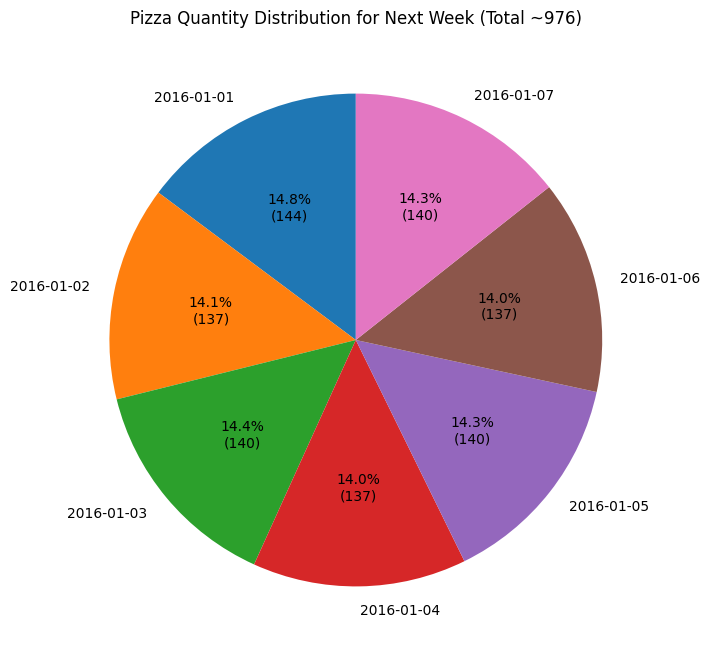

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Your ARIMA forecast results
forecast = pd.Series([
    144.289447,
    137.431371,
    140.032370,
    136.986484,
    139.984049,
    136.983070,
    139.982037
], index=pd.date_range("2016-01-01", periods=7, freq="D"))

# Total pizzas next week
weekly_total = forecast.sum()
print("Total pizzas needed next week:", round(weekly_total))

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(forecast, labels=forecast.index.strftime('%Y-%m-%d'),
        autopct=lambda p: f'{p:.1f}%\n({p*weekly_total/100:.0f})',
        startangle=90)

plt.title("Pizza Quantity Distribution for Next Week (Total ~976)")
plt.show()
